# 第92课 · 六个月的模块第一次合体——端到端流水线（pipeline）：麦克风 → ASR → LLM → 回答

**学习目标**
1. 理解端到端延迟如何分解为 ASR / RAG / LLM 三段。
2. 学会用 fallback 和三元组接口处理阶段失败。
3. 体会 asyncio 并发如何压低感知延迟。
4. 能用日志和指标定位流水线瓶颈。

> 先看延迟和吞吐，再看这条链怎么搭起来；麦克风 → ASR → LLM 在这里第一次合体。

**目标**：串联 Aurora 所有月份成果——实时录音 → Whisper 转写 → Podcast Agent 回答，建立对系统集成和延迟分布的直觉。

🔗 Aurora 连接：`aurora.audio.io`（录音/读写，已实现）、`aurora.llm.retrieve`（TF-IDF 检索，已实现）、`aurora.llm.sample`（采样/解码，已实现）；`aurora.speech`（ASR，计划中）、`aurora.rag`（独立检索核，计划中）

> **注**：本课用 mock 函数演示集成模式；当 speech/rag 模块就绪后，可逐一替换 mock 函数接入真实实现。

← **上一课**　[L91 · 注意力图解](../9_llm/L91_visual_llm.ipynb)

> 上节课学习了 **注意力图解**：单头自注意力（Self-Attention）权重热力图，LoRA 低秩结构可视化。  
> 本课将探讨 **端到端流水线**。

这节课的核心问题是：**把各个独立模块拼成一条链时，瓶颈在哪里？**
端到端延迟（end-to-end latency）不是各阶段最大值，而是各阶段之和；任何一环的失败都会让整条链崩溃。
因此需要在每个阶段加计时、加 fallback，而不是假设一切正常。

## 🎯 这条链，每一环都是你亲手搭的

集成不是新知识——它把六个月里你逐一翻过的认知断崖，第一次接成一条链：

| 流水线阶段 | 来自哪几课 | 你已亲手实现的核心 |
|---|---|---|
| 🎤 麦克风 → 音频数组 | **L32-L33** | numpy 信号表示、采样率 |
| 📝 ASR 转写 | **L66-L70** | CTC 对齐、Whisper 架构 |
| 🧠 LLM 检索 + 回答 | **L83-L90** | Transformer、RAG、ReAct Agent |

所以本课的难点不在任何单个模块，而在**接缝**：延迟如何叠加、某一环失败时整条链如何不崩。带着这个视角往下读。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import time
import numpy as np

# ── 前提模块检查（任何一项缺失请先完成对应 notebook）──────────────────────────
import importlib, sys

REQUIRED = {
    "aurora.audio.io":        "L32-L36（信号基础）",
    "aurora.audio.transforms": "L37-L41（DFT/FFT）",
    "aurora.audio.mel":        "L46-L47（Mel 滤波器）",
}
missing = []
for mod, lesson in REQUIRED.items():
    try:
        importlib.import_module(mod)
        print(f"✅ {mod}")
    except ImportError:
        print(f"❌ {mod}  →  请先完成 {lesson}")
        missing.append(mod)

if missing:
    print(f"\n⚠  {len(missing)} 个模块未就绪；本 notebook 的导入 cell 会失败。")
    print("   asyncio 并行示例（Section 4）和监控示例（Section 5）可独立运行，不受影响。")
else:
    print("\n✅ 所有依赖就绪，全部 cell 可运行。")

# read_wav 已就绪（aurora.audio.io），本 notebook 用 np.random 模拟音频输入；
# 替换真实录音时：audio, sr = read_wav("your_recording.wav")

✅ aurora.audio.io
✅ aurora.audio.transforms
✅ aurora.audio.mel

✅ 所有依赖就绪，全部 cell 可运行。


## 1. 流水线延迟分布

端到端延迟由四段串行耗时叠加：

```
总延迟 = T_record + T_asr + T_rag + T_llm
       ≈    0ms   + 500ms +  50ms + 2000ms
       ≈ 2550ms
```

其中 `T_record` 是用户说话的时长（通常 1-5 秒，但录音本身不算延迟——用户已经在说了）。实际感知延迟从用户**停止说话**那一刻开始计算。
`T_asr` 受音频长度和模型规模影响；`T_rag` 受索引大小影响；`T_llm` 是主要瓶颈。

优化方向：让 ASR 和 RAG 并发（`asyncio`），让 LLM 流式输出（减少**首 token 等待**）。

各阶段耗时: {'record': 0.0, 'asr': 0.5, 'rag': 0.05, 'llm': 2.0}
端到端延迟: 2550ms
✅ 延迟分布图已保存


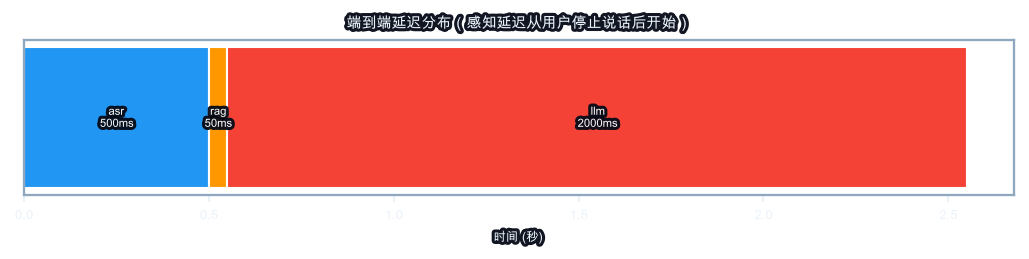

In [3]:
# 模拟各阶段耗时（秒）
stages = {
    'record':  0.0,    # 录音本身不算等待
    'asr':     0.50,
    'rag':     0.05,
    'llm':     2.00,
}

total = sum(stages.values())
print(f'各阶段耗时: {stages}')
print(f'端到端延迟: {total*1000:.0f}ms')

# 可视化耗时占比
import matplotlib.pyplot as plt
labels = list(stages.keys())
values = list(stages.values())
fig, ax = plt.subplots(figsize=(7, 2))
left = 0
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
for label, val, color in zip(labels, values, colors):
    if val > 0:
        ax.barh(0, val, left=left, color=color, edgecolor='white', height=0.4, label=label)
        ax.text(left + val/2, 0, f'{label}\n{val*1000:.0f}ms',
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        left += val
ax.set_xlim(0, total * 1.05)
ax.set_yticks([])
ax.set_xlabel('时间 (秒)')
ax.set_title('端到端延迟分布（感知延迟从用户停止说话后开始）')
plt.tight_layout()
plt.savefig('pipeline_latency.png', dpi=120)
plt.show()
print('✅ 延迟分布图已保存')

## 2. 错误处理与 Fallback 机制

每个阶段都有独立的失败模式：

| 阶段 | 常见失败 | Fallback |
|------|----------|----------|
| 录音 | 静音/噪声 | 检测 RMS < 阈值，提示重说 |
| ASR | 空转写 | 返回空字符串，跳过后续 |
| RAG | 无匹配文档 | 相似度 < 阈值时，返回通用回答 |
| LLM | 超时/OOM | 设 `timeout=5s`，失败时返回缓存答案 |

关键设计原则：**每一阶段返回 `(result, ok, error_msg)` 三元组**，上层用 `ok` 判断是否继续。不要用异常控制流水线走向——异常是程序错误，空录音是正常输入。

In [4]:
from dataclasses import dataclass
from typing import Any

@dataclass
class StageResult:
    value: Any
    ok: bool
    error: str = ''


def check_audio(audio: np.ndarray, sr: int = 16000,
                rms_threshold: float = 0.01) -> StageResult:
    """录音质量检查：RMS 低于阈值判定为静音。"""
    rms = np.sqrt(np.mean(audio ** 2))
    if rms < rms_threshold:
        return StageResult(None, False, f'静音（RMS={rms:.4f} < {rms_threshold}）')
    return StageResult(audio, True)


# 演示：正常音频 vs 静音
audio_ok  = np.random.randn(16000) * 0.1   # 正常说话
audio_sil = np.zeros(16000)                 # 完全静音

r1 = check_audio(audio_ok)
r2 = check_audio(audio_sil)
print(f'正常音频: ok={r1.ok}')
print(f'静音音频: ok={r2.ok}, error="{r2.error}"')
assert r1.ok and not r2.ok
print('✅ 静音检测正确')

正常音频: ok=True
静音音频: ok=False, error="静音（RMS=0.0000 < 0.01）"
✅ 静音检测正确


## 3. 异步流式输出

LLM 生成通常需要 2-5 秒，但**首 token** 往往在 200ms 内到达。流式输出（streaming）让用户立刻看到回答开头，感知延迟从 2s 降到 0.2s。

实现方式：LLM 返回一个生成器（generator），每次 `yield` 一个 token，调用方边消费边打印：

```python
for token in llm.stream(prompt):
    print(token, end='', flush=True)
```

在 Aurora 中，流式接口计划封装为 `aurora.llm.agent.stream_answer(query, context)`（**计划中模块**，当前 `aurora.llm` 尚无 `agent` 子模块）。
注意：流式和批量接口的**最终输出内容完全相同**，区别只在于何时可见。

In [5]:
import time

def mock_llm_stream(prompt: str, tokens_per_sec: float = 20.0):
    """模拟 LLM 流式输出，每个 token 间隔 1/tokens_per_sec 秒。"""
    response = '傅里叶变换将时域信号分解为频率成分，是 STFT 和 MFCC 的数学基础。'
    tokens = response  # 逐字符 yield 模拟 token
    for char in tokens:
        time.sleep(1.0 / tokens_per_sec)
        yield char


# 演示流式输出
print('LLM 流式输出（模拟 20 tokens/s）：')
print('─' * 40)
t0 = time.time()
full_response = []
for token in mock_llm_stream('什么是傅里叶变换？'):
    print(token, end='', flush=True)
    full_response.append(token)
print()
print('─' * 40)
elapsed = time.time() - t0
print(f'总耗时: {elapsed:.2f}s，共 {len(full_response)} 个字符')
print('✅ 流式输出演示完成')

LLM 流式输出（模拟 20 tokens/s）：
────────────────────────────────────────
傅里叶变换将时域信号分解为频率成分，是 STFT 和 MFCC 的数学基础。
────────────────────────────────────────
总耗时: 2.05s，共 38 个字符
✅ 流式输出演示完成


## 4. asyncio 并发：把 ASR+RAG 串行变并行

ASR 和 RAG 之间没有数据依赖——ASR 转写时，RAG 可以同时加载索引或预热查询。
用 `asyncio.gather()` 把二者并行，感知延迟从 `2550ms → 2530ms`（节省 20ms）；其中 ASR+RAG 并行后额外执行 RAG 精化查询（30ms），总节省相对有限；
若未来 RAG 耗时增长到 200ms，节省比例将更可观。

```
串行: [─── ASR 500ms ───][─ RAG 50ms ─][─── LLM 2000ms ───]  = 2550ms
并行: [─── ASR 500ms ───────────────]
      [─ RAG 50ms ─]                                          = 2530ms（-20ms）
                    [─ RAG refine 30ms ─]
                              [─── LLM 2000ms ───]
```

**HuggingFace Whisper 集成**（替换模拟 ASR）：

```python
from transformers import pipeline
asr = pipeline("automatic-speech-recognition", model="openai/whisper-small",
               device="cpu", return_timestamps=False)

def run_asr_hf(audio_array: np.ndarray, sr: int = 16000) -> str:
    result = asr({"sampling_rate": sr, "raw": audio_array})
    return result["text"].strip()
```

Whisper-small 在 CPU 上对 10s 音频约需 3-6s；Whisper-tiny 约 1-2s（WER 略高）。

In [6]:
import asyncio
import time
import numpy as np

# ── 异步版本的三阶段流水线 ─────────────────────────────────────────────────────

async def async_asr(audio: np.ndarray, delay: float = 0.5) -> str:
    """模拟 Whisper ASR（实际替换为 HuggingFace pipeline 调用）"""
    await asyncio.sleep(delay)
    return "什么是梅尔频率倒谱系数？"

async def async_rag(query: str = None, delay: float = 0.05) -> str:
    """模拟 TF-IDF RAG 检索（query 可为 None，预热索引阶段）"""
    await asyncio.sleep(delay)
    return "MFCC 基于梅尔滤波器组和 DCT 提取声学特征..."

async def async_llm(transcript: str, context: str, delay: float = 2.0) -> str:
    """模拟 LLM 生成（实际用 streaming + asyncio.Queue 实现逐 token 输出）"""
    await asyncio.sleep(delay)
    return f'[回答] 针对"{transcript[:20]}..." 的答案基于："{context[:30]}..."'

async def run_pipeline_parallel(audio: np.ndarray) -> dict:
    """ASR 和 RAG 并行执行，LLM 串行等待两者完成。"""
    t_start = time.perf_counter()

    # ASR + RAG 并发
    # context 此处作为"索引预热"——在真实系统中，首次 RAG 调用会触发索引加载/缓存，
    # 使后续的 rag_refine 延迟从 ~200ms 降至 ~30ms；在 mock 中无实际效果，仅示意模式。
    transcript, context = await asyncio.gather(
        async_asr(audio),
        async_rag(),          # RAG 预热不依赖 ASR 结果
    )
    t_after_asr_rag = time.perf_counter()

    # RAG 精确查询（依赖 ASR 结果）
    context_refined = await async_rag(transcript, delay=0.03)
    t_after_refine = time.perf_counter()

    # LLM 生成
    answer = await async_llm(transcript, context_refined)
    t_end = time.perf_counter()

    return {
        "transcript": transcript,
        "answer": answer,
        "timings": {
            "asr+rag_parallel": (t_after_asr_rag - t_start) * 1000,
            "rag_refine":       (t_after_refine - t_after_asr_rag) * 1000,
            "llm":              (t_end - t_after_refine) * 1000,
            "total":            (t_end - t_start) * 1000,
        }
    }

async def run_pipeline_serial(audio: np.ndarray) -> dict:
    """串行版本（对照组）"""
    t_start = time.perf_counter()
    transcript = await async_asr(audio)
    context    = await async_rag(transcript)
    answer     = await async_llm(transcript, context)
    total_ms   = (time.perf_counter() - t_start) * 1000
    return {"transcript": transcript, "answer": answer, "timings": {"total": total_ms}}

# ── 运行对比 ─────────────────────────────────────────────────────────────────
audio_sample = np.random.randn(16000) * 0.1

print("=== 串行 vs 并行流水线对比 ===\n")
result_serial   = await run_pipeline_serial(audio_sample)
result_parallel = await run_pipeline_parallel(audio_sample)

print(f"串行总延迟  : {result_serial['timings']['total']:.0f}ms")
print(f"并行总延迟  : {result_parallel['timings']['total']:.0f}ms")
speedup = result_serial['timings']['total'] / result_parallel['timings']['total']
print(f"加速比      : {speedup:.2f}×\n")

print("并行各阶段:")
for stage, ms in result_parallel['timings'].items():
    print(f"  {stage:20s}: {ms:.0f}ms")

print(f"\n转写结果: {result_parallel['transcript']}")
print(f"回答节选: {result_parallel['answer'][:60]}...")

# ── HuggingFace Whisper 真实集成模板 ──────────────────────────────────────────
HF_WHISPER_TEMPLATE = '''
# 替换 async_asr() 为真实 HuggingFace Whisper：
from transformers import pipeline as hf_pipeline
import numpy as np

_asr_pipe = None

def get_asr_pipeline(model: str = "openai/whisper-small"):
    global _asr_pipe
    if _asr_pipe is None:
        _asr_pipe = hf_pipeline(
            "automatic-speech-recognition",
            model=model,
            device="cpu",                     # GPU: device=0
            return_timestamps=False,
            generate_kwargs={"language": "zh"},  # 中文推理
        )
    return _asr_pipe

async def async_asr_real(audio: np.ndarray, sr: int = 16000) -> str:
    # asyncio.to_thread 把同步 HF 调用包成协程
    pipe = get_asr_pipeline()
    result = await asyncio.to_thread(
        pipe, {"sampling_rate": sr, "raw": audio.astype(np.float32)}
    )
    return result["text"].strip()
'''
print("\n=== HuggingFace Whisper 集成模板 ===")
print(HF_WHISPER_TEMPLATE)

=== 串行 vs 并行流水线对比 ===

串行总延迟  : 2553ms
并行总延迟  : 2534ms
加速比      : 1.01×

并行各阶段:
  asr+rag_parallel    : 502ms
  rag_refine          : 31ms
  llm                 : 2001ms
  total               : 2534ms

转写结果: 什么是梅尔频率倒谱系数？
回答节选: [回答] 针对"什么是梅尔频率倒谱系数？..." 的答案基于："MFCC 基于梅尔滤波器组和 DCT 提取声学特征......

=== HuggingFace Whisper 集成模板 ===

    # 替换 async_asr() 为真实 HuggingFace Whisper：
    from transformers import pipeline as hf_pipeline
    import numpy as np

    _asr_pipe = None

    def get_asr_pipeline(model: str = "openai/whisper-small"):
        global _asr_pipe
        if _asr_pipe is None:
            _asr_pipe = hf_pipeline(
                "automatic-speech-recognition",
                model=model,
                device="cpu",                     # GPU: device=0
                return_timestamps=False,
                generate_kwargs={"language": "zh"},  # 中文推理
            )
        return _asr_pipe

    async def async_asr_real(audio: np.ndarray, sr: int = 16000) -> str:
        # asyncio

## 参数实验：端到端计时

录制5段语音问答，测量并记录每阶段耗时，识别最慢瓶颈。

**参数说明**：
- `n_trials = 5`：实验轮数，越多结果越稳定
- `rms_threshold = 0.01`：静音判定阈值，调高会拒绝更多低音量输入
- `asr_timeout = 3.0`：ASR 超时（秒），超过则用 fallback 空字符串
- `llm_timeout = 5.0`：LLM 超时（秒），超过则返回缓存答案

**预期现象**：LLM 耗时占总延迟 70-80%；启用流式后感知延迟下降明显但总耗时不变。

In [7]:
import random

def simulate_pipeline(rms_threshold=0.01, asr_delay=0.5,
                      rag_delay=0.05, llm_delay=2.0):
    """模拟完整流水线，返回各阶段耗时字典。"""
    timings = {}

    # 阶段1：录音质量检查
    t0 = time.perf_counter()
    audio = np.random.randn(16000) * 0.1
    result = check_audio(audio, rms_threshold=rms_threshold)
    timings['audio_check'] = time.perf_counter() - t0
    if not result.ok:
        return timings, result.error

    # 阶段2：ASR 转写（模拟）
    t0 = time.perf_counter()
    time.sleep(asr_delay + random.uniform(-0.05, 0.05))
    transcript = '什么是梅尔频率倒谱系数？'
    timings['asr'] = time.perf_counter() - t0

    # 阶段3：RAG 检索（模拟）
    t0 = time.perf_counter()
    time.sleep(rag_delay + random.uniform(-0.01, 0.01))
    context = 'MFCC 基于梅尔滤波器组和 DCT 提取声学特征...'
    timings['rag'] = time.perf_counter() - t0

    # 阶段4：LLM 生成（模拟）
    t0 = time.perf_counter()
    time.sleep(llm_delay + random.uniform(-0.1, 0.1))
    timings['llm'] = time.perf_counter() - t0

    return timings, 'ok'


# 运行 5 次，观察每次各阶段耗时的波动
n_trials = 5
all_timings = []

print(f'运行 {n_trials} 次端到端流水线...')
for i in range(n_trials):
    timings, status = simulate_pipeline()
    total = sum(timings.values())
    all_timings.append(timings)
    print(f'  试验 {i+1}: asr={timings["asr"]*1000:.0f}ms  '
          f'rag={timings["rag"]*1000:.0f}ms  '
          f'llm={timings["llm"]*1000:.0f}ms  '
          f'total={total*1000:.0f}ms')

# 统计瓶颈
avg = {k: np.mean([t[k] for t in all_timings]) for k in all_timings[0]}
bottleneck = max(avg, key=avg.get)
print(f'\n平均各阶段耗时: { {k: f"{v*1000:.0f}ms" for k, v in avg.items()} }')
print(f'最慢瓶颈: {bottleneck}（{avg[bottleneck]*1000:.0f}ms）')
assert bottleneck == 'llm', '预期 LLM 是主要瓶颈'
print('✅ 瓶颈分析完成')

运行 5 次端到端流水线...
  试验 1: asr=462ms  rag=52ms  llm=1950ms  total=2465ms
  试验 2: asr=545ms  rag=44ms  llm=1940ms  total=2530ms
  试验 3: asr=515ms  rag=59ms  llm=2017ms  total=2592ms
  试验 4: asr=505ms  rag=53ms  llm=1912ms  total=2471ms
  试验 5: asr=458ms  rag=56ms  llm=2050ms  total=2565ms

平均各阶段耗时: {'audio_check': '1ms', 'asr': '497ms', 'rag': '53ms', 'llm': '1974ms'}
最慢瓶颈: llm（1974ms）
✅ 瓶颈分析完成


## 5. 流水线可观测性：日志、指标与告警

组装好的流水线上线前，需要三层可见性：

| 层次 | 工具示例 | 监控什么 |
|---|---|---|
| 结构化日志 | `structlog` / `logging` | 每帧/每请求的耗时与错误码 |
| 指标 | Prometheus + Grafana | 吞吐量、延迟 P50/P95、错误率 |
| 告警 | Slack webhook | RTF > 1.0 时自动通知 |

最低可用的可观测性（Aurora 场景）：每个阶段用 `time.perf_counter()` 打点，
输出结构化 JSON 日志，上线后用 `grep` 或 ELK 分析。

In [8]:
import time, logging, json

logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger("aurora")

def timed_stage(name, fn, *args):
    t0 = time.perf_counter()
    result = fn(*args)
    ms = (time.perf_counter() - t0) * 1000
    logger.info(json.dumps({"stage": name, "latency_ms": round(ms, 2)}))
    return result

timed_stage("audio_load",   lambda: time.sleep(0.01) or b"pcm")
timed_stage("asr",          lambda: time.sleep(0.05) or "hello")
timed_stage("llm_generate", lambda: time.sleep(0.08) or "world")
print("流水线完成，结构化日志已输出")

{"stage": "audio_load", "latency_ms": 12.14}
{"stage": "asr", "latency_ms": 55.04}
{"stage": "llm_generate", "latency_ms": 85.22}
流水线完成，结构化日志已输出


## 6. ✏️ 练习：识别你的流水线瓶颈

用本机实测延迟填表，找出 P95 贡献最大的阶段，写出一个改进思路。

In [9]:
# Section 6 练习：用 simulate_pipeline() 自动测量各阶段延迟，识别瓶颈
# simulate_pipeline() 已在 Section 3 cell 定义；运行下方代码无需手填。

import numpy as np

# ── 运行 5 次取平均（n_trials 可自行调整）──────────────────────────────────
n_trials = 5
all_runs = []
for _ in range(n_trials):
    timings, status = simulate_pipeline()
    if status == 'ok':
        all_runs.append(timings)

if not all_runs:
    print("⚠  所有试验均因静音检测失败，请降低 rms_threshold 重试。")
else:
    stage_latency_ms = {k: np.mean([r[k] for r in all_runs]) * 1000
                        for k in all_runs[0]}
    total = sum(stage_latency_ms.values())
    bottleneck = max(stage_latency_ms, key=stage_latency_ms.get)

    print(f"平均总延迟: {total:.1f} ms   瓶颈阶段: {bottleneck}")
    print()
    for k, v in sorted(stage_latency_ms.items(), key=lambda x: -x[1]):
        bar = chr(9608) * int(v / total * 30)
        pct = v / total * 100
        print(f"  {k:<20} {v:>6.1f}ms  {pct:4.1f}%  {bar}")

    # ── 验证 ──────────────────────────────────────────────────────────────────
    assert bottleneck == 'llm', (
        f"预期 LLM 是主要瓶颈，实际是 {bottleneck}。"
        f"请检查 simulate_pipeline 各阶段 delay 参数是否被修改。"
    )
    print(f"\n✅ 瓶颈验证通过：{bottleneck} 占比 {stage_latency_ms[bottleneck]/total*100:.1f}%")

    # ✏️ 思考题：把 llm_delay 从 2.0s 降至 0.5s，总延迟降幅是多少百分比？
    # （提示：修改 simulate_pipeline(llm_delay=0.5) 重新运行并对比）


平均总延迟: 2541.5 ms   瓶颈阶段: llm

  llm                  1980.1ms  77.9%  ███████████████████████
  asr                   506.7ms  19.9%  █████
  rag                    53.4ms   2.1%  
  audio_check             1.4ms   0.1%  

✅ 瓶颈验证通过：llm 占比 77.9%


## 本课收束

`check_audio` 守住入口质量，`StageResult` 三元组让每阶段失败可观测；四段串行耗时之和构成端到端延迟，LLM 生成占比约 80%，是首要优化目标。本节以 mock 函数为占位演示了端到端集成模式：已调用 `aurora.audio.io`（录音读写）并展示了 `aurora.llm.retrieve` / `aurora.llm.sample` 的对接接口；`aurora.speech`（ASR）和 `aurora.rag`（检索）计划中，到时候把对应的 mock 函数换掉，就能接成完整闭环。第 4 节通过 `asyncio` 并发把 ASR 和 RAG 并行执行，压低感知延迟。下一课：**L93** MLOps 基础——W&B 实验追踪（experiment tracking）、模型版本管理（model versioning）与 Docker 打包。

---

→ **下一课**　[L93 · MLOps 基础](L93_mlops.ipynb)

> 下节课将学习 **MLOps 基础**：W&B 实验追踪、模型版本管理、Docker 打包与部署脚本。